# 🧪 Model Lab: Random Forest (Optimized)

이 노트북은 랜덤 포레스트 모델의 하이퍼파라미터를 최적화하고, 주가 방향성 예측 성능을 다각도로 평가합니다.

### 🧪 실험 설정
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **최적화 전략:** TimeSeriesSplit 기반 GridSearchCV (정확도 기준)

In [5]:
# 1. 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style="whitegrid")

In [6]:
# 2. 데이터 준비
df = pd.read_csv("../data/processed/selected_features_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'ticker'])

exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70/15/15 시계열 분할
n = len(df)
tr_idx, val_idx = int(n*0.7), int(n*0.85)

X_train, y_train = X.iloc[:tr_idx], y.iloc[:tr_idx]
X_val, y_val = X.iloc[tr_idx:val_idx], y.iloc[tr_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (1024, 25), Val set: (220, 25), Test set: (220, 25)


In [7]:
# 3. 모델 학습 및 파라미터 최적화 (개선 버전)
from sklearn.model_selection import PredefinedSplit

# PredefinedSplit 설정 (Val 데이터 기준 최적화)
test_fold = np.concatenate([
    np.full(len(X_train), -1),
    np.full(len(X_val), 0)
])
ps = PredefinedSplit(test_fold)

X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# 그리드 조정: 과적합 방지를 위해 max_depth 제한 및 min_samples_leaf 확장
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

# GridSearchCV 수행 (F1-score 기준)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=ps,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("--- 최적 파라미터 검색 중 (Val 기준 & F1 최적화)... ---")
grid_search.fit(X_combined, y_combined)

best_model = grid_search.best_estimator_
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 검증 점수 (F1): {grid_search.best_score_:.4f}")

def get_metrics(model, X_set, y_set, label):
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)[:, 1]
    return {
        'Set': label,
        'Accuracy': accuracy_score(y_set, preds),
        'Precision': precision_score(y_set, preds),
        'Recall': recall_score(y_set, preds),
        'F1': f1_score(y_set, preds),
        'AUC': roc_auc_score(y_set, probs)
    }

results = pd.DataFrame([
    get_metrics(best_model, X_train, y_train, 'Train'),
    get_metrics(best_model, X_val, y_val, 'Val'),
    get_metrics(best_model, X_test, y_test, 'Test')
])

print("\n--- Random Forest Performance (Optimized) ---")
display(results)

--- 최적 파라미터 검색 중 (Val 기준 & F1 최적화)... ---
Fitting 1 folds for each of 486 candidates, totalling 486 fits
최적 파라미터: {'class_weight': None, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
최적 검증 점수 (F1): 0.6034

--- Random Forest Performance (Optimized) ---


,Set,Accuracy,Precision,Recall,F1,AUC
0,Train,0.726562,0.669164,0.972777,0.792899,0.859471
1,Val,0.854545,0.804511,0.946903,0.869919,0.959722
2,Test,0.563636,0.584071,0.573913,0.578947,0.554037


--- 최적 파라미터로 트리 수 증가에 따른 Accuracy 추적 중 ---


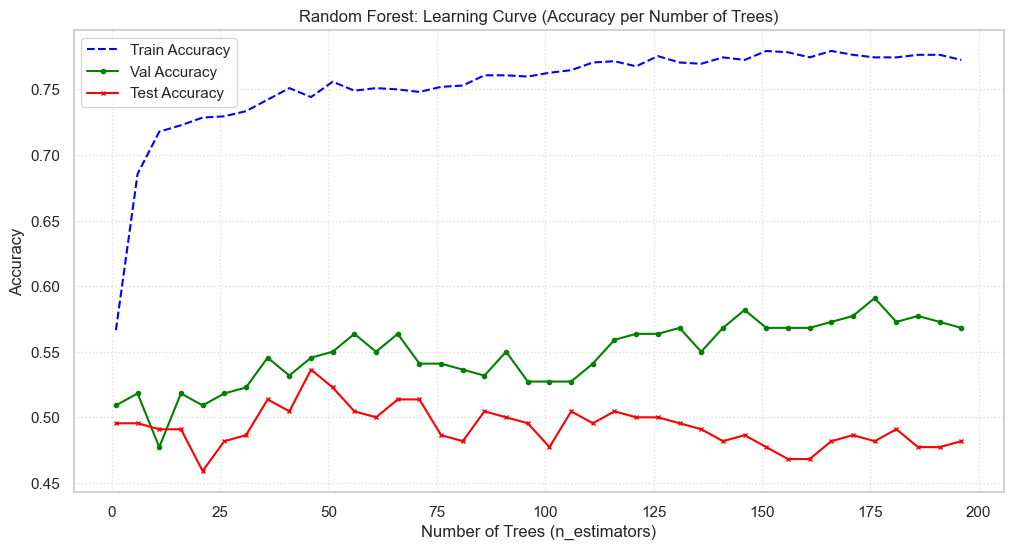

최종 결과 (196 trees) - Train: 0.7725, Val: 0.5682, Test: 0.4818


In [8]:
# 4. Iteration(Tree 수)별 학습 곡선 분석
# Random Forest는 warm_start를 사용하여 트리를 하나씩 추가하며 성능을 측정합니다.

best_params = grid_search.best_params_.copy()
# n_estimators는 루프에서 제어하므로 삭제
if 'n_estimators' in best_params:
    del best_params['n_estimators']

model_iter = RandomForestClassifier(**best_params, warm_start=True, n_estimators=1, random_state=42)

train_accs, val_accs, test_accs = [], [], []
tree_range = range(1, 201, 5) # 1개부터 200개까지 5개씩 증가

print(f"--- 최적 파라미터로 트리 수 증가에 따른 Accuracy 추적 중 ---")

for n_trees in tree_range:
    model_iter.n_estimators = n_trees
    model_iter.fit(X_train, y_train)
    
    train_accs.append(accuracy_score(y_train, model_iter.predict(X_train)))
    val_accs.append(accuracy_score(y_val, model_iter.predict(X_val)))
    test_accs.append(accuracy_score(y_test, model_iter.predict(X_test)))

# 학습 곡선 시각화
plt.figure(figsize=(12, 6))
plt.plot(tree_range, train_accs, label='Train Accuracy', color='blue', linestyle='--')
plt.plot(tree_range, val_accs, label='Val Accuracy', color='green', marker='o', markersize=3)
plt.plot(tree_range, test_accs, label='Test Accuracy', color='red', marker='x', markersize=3)

plt.title('Random Forest: Learning Curve (Accuracy per Number of Trees)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"최종 결과 ({tree_range[-1]} trees) - Train: {train_accs[-1]:.4f}, Val: {val_accs[-1]:.4f}, Test: {test_accs[-1]:.4f}")

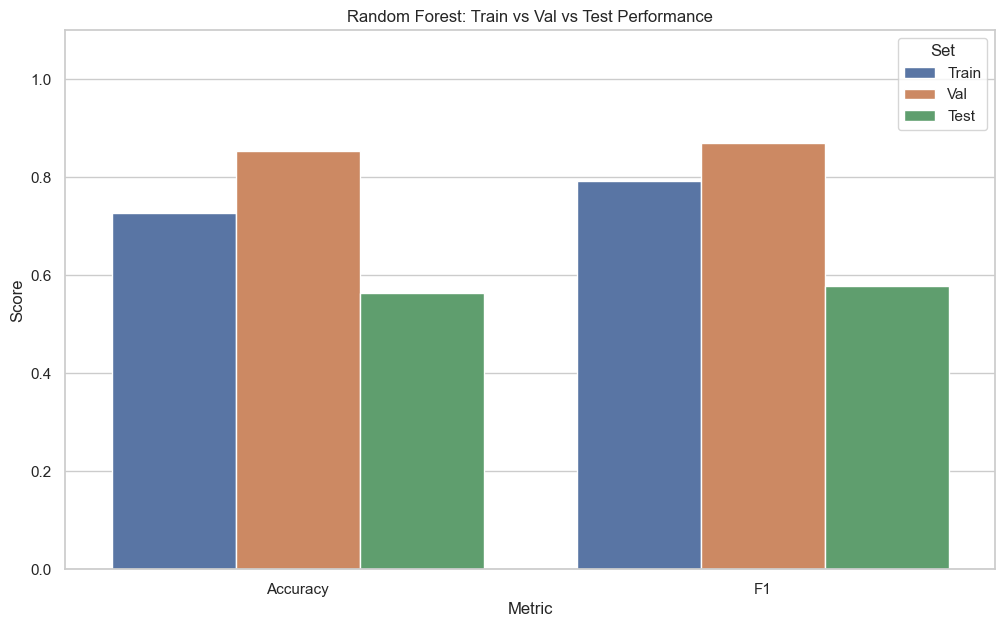

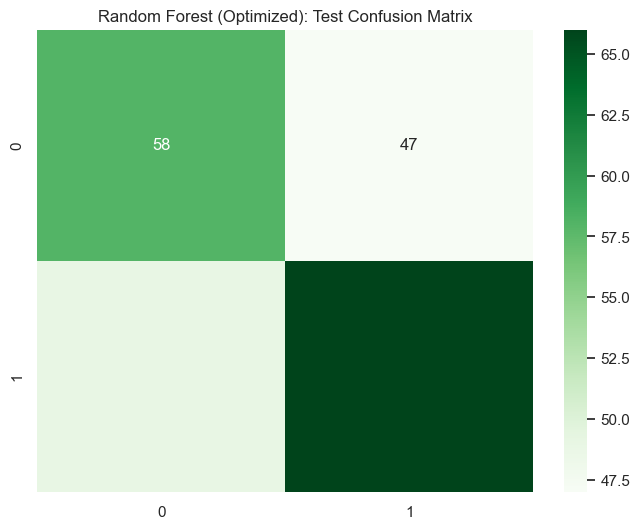

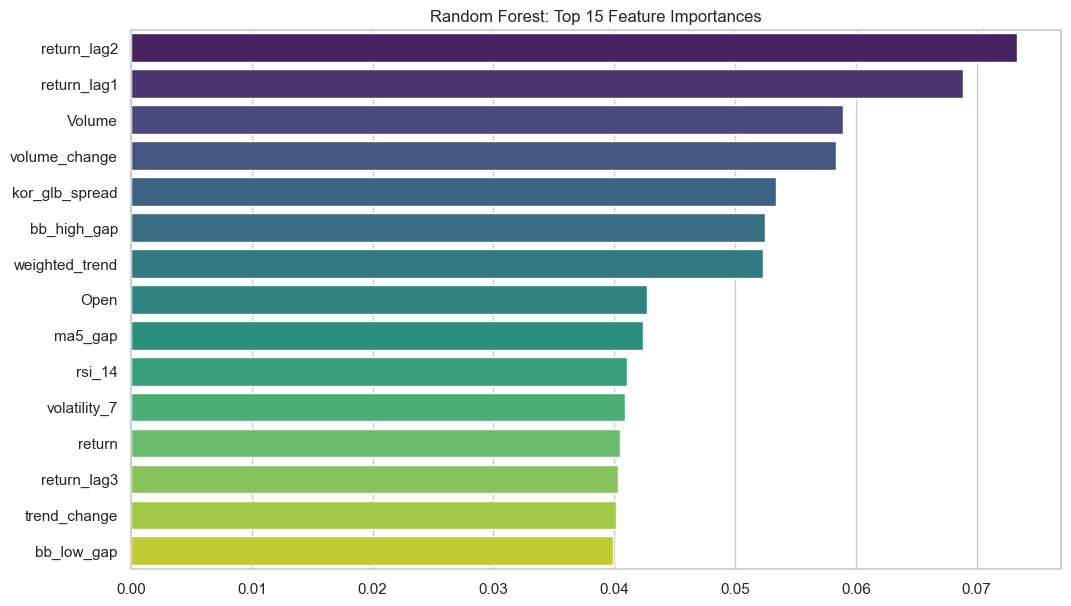

In [9]:
# 4. 결과 시각화

# Accuracy & F1 비교 차트
melted_results = results.melt(id_vars='Set', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')
sns.barplot(data=melted_results, x='Metric', y='Score', hue='Set')
plt.title("Random Forest: Train vs Val vs Test Performance")
plt.ylim(0, 1.1)
plt.show()

# 혼동 행렬
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest (Optimized): Test Confusion Matrix')
plt.show()

# 변수 중요도
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False).head(15)
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Random Forest: Top 15 Feature Importances")
plt.show()